In [1]:
#load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
df = pd.read_csv('bank.csv', sep=';')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTarget distribution:")
print(df['y'].value_counts())
df.head()

Shape: (4521, 17)

Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Target distribution:
no     4000
yes     521
Name: y, dtype: int64


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [2]:
#data info
df.info()
print("\nMissing values:")
print(df.isnull().sum().sum()) 
print("\nUnique values in categorical columns:")
for col in df.select_dtypes('object').columns:
    print(f"{col}: {df[col].nunique()} unique")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB

Missing values:
0

Unique values in categorical columns:
job: 12 unique
marital: 3 unique
educatio

In [4]:
#preprocessing
from sklearn.preprocessing import LabelEncoder
df_model = df.copy()
df_model['y'] = df_model['y'].map({'no': 0, 'yes': 1})
binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    df_model[col] = df_model[col].map({'no': 0, 'yes': 1, 'unknown': 0})
cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
print("After encoding:")
df_model.head()
print(f"\nShape: {df_model.shape}")

After encoding:

Shape: (4521, 17)


In [5]:
#train test
X = df_model.drop('y', axis=1)
y = df_model['y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print("Model trained")

Train size: (3616, 16), Test size: (905, 16)
Model trained


Accuracy: 89.17%

Confusion Matrix:


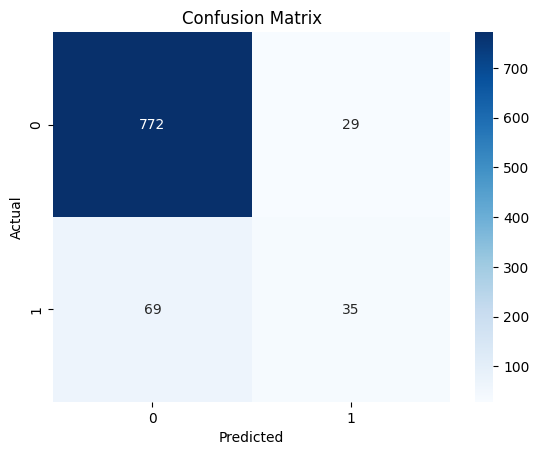


Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.92      0.96      0.94       801
    Purchase       0.55      0.34      0.42       104

    accuracy                           0.89       905
   macro avg       0.73      0.65      0.68       905
weighted avg       0.88      0.89      0.88       905



In [6]:
#evaluate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

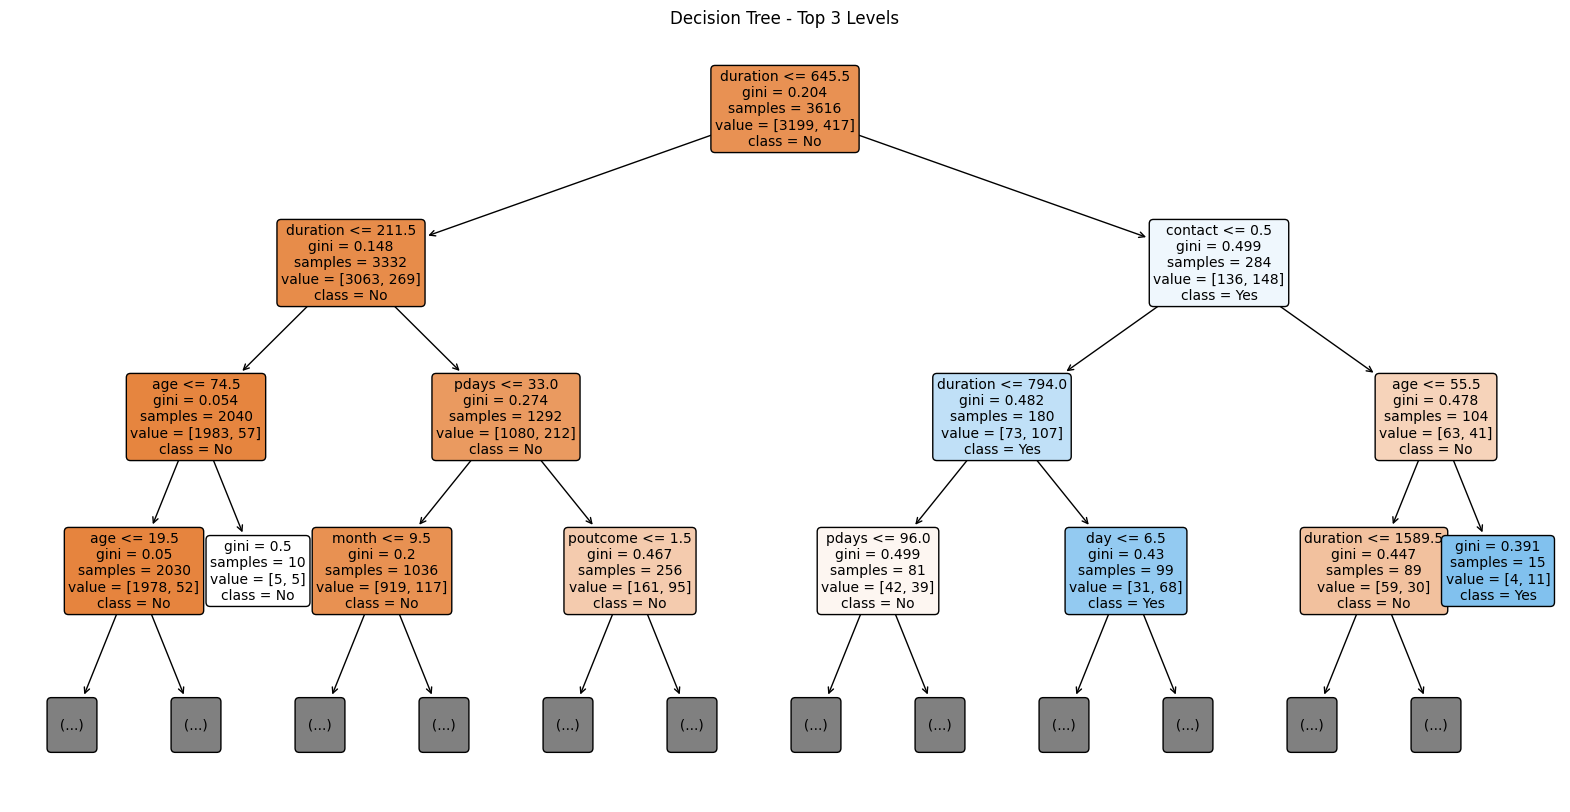

In [7]:
#visualize
plt.figure(figsize=(20,10))
plot_tree(dt,
          feature_names=X.columns,
          class_names=['No','Yes'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3) 
plt.title('Decision Tree - Top 3 Levels')
plt.show()

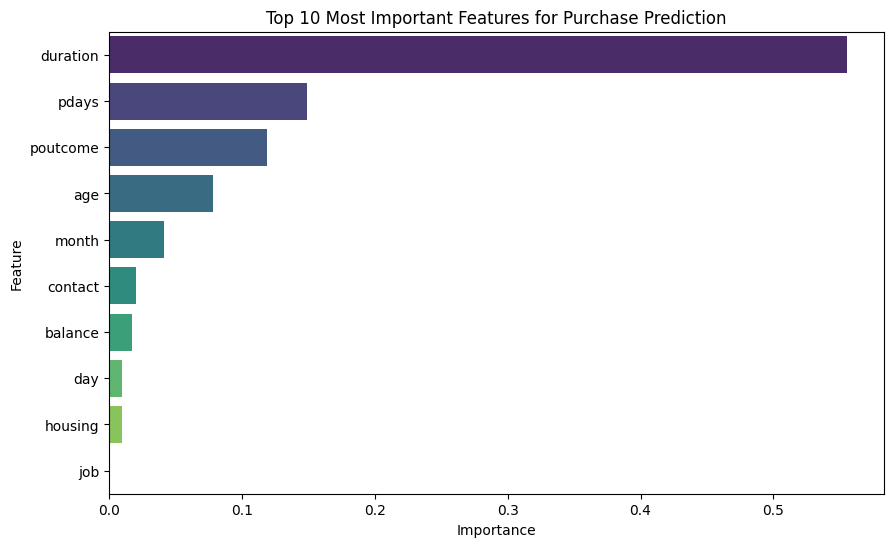

Top 5 features:
     Feature  Importance
11  duration    0.555508
13     pdays    0.149311
15  poutcome    0.118611
0        age    0.078317
10     month    0.041705


In [11]:
#feature importance
importance = pd.DataFrame({'Feature': X.columns,'Importance': dt.feature_importances_}).sort_values('Importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Most Important Features for Purchase Prediction')
plt.show()
print("Top 5 features:")
print(importance.head())